# PRIM Pipeline Notebook

This notebook runs the main PRIM workflow for prostate mask tokenization, token-prior training, sample decoding, and basic output diagnostics. The structure is intentionally sequential so that each stage can be executed independently or as part of a full experiment.


## Environment Setup

This section configures the execution environment for either Google Colab or a local machine, installs the required dependencies in Colab, and checks that the local project files are being imported from the expected directory.


In [1]:
# Detect whether the notebook is running in Google Colab and configure the environment.
import sys, torch

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
  from google.colab import drive
  drive.mount('/content/drive')
  !pip -q install pytorch-lightning monai
  %cd /content/drive/MyDrive/PRIM

# Import one local module to verify that the project is visible from the current working directory.
import convnet3D_utils, inspect, os


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 119.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 72.3 MB/s eta 0:00:00
/content/drive/MyDrive/PRIM


In [2]:
# Print basic runtime information for reproducibility and GPU availability checks.
print("Python:", sys.version)
print("Torch:", torch.__version__, "CUDA available:", torch.cuda.is_available())
# Confirm that local project files are being imported from the expected location.
print("convnet3D_utils file:", convnet3D_utils.__file__)
print("trainprostVQ exists:", os.path.exists("trainprostVQ.py"))

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Torch: 2.10.0+cu128 CUDA available: True
convnet3D_utils file: /content/drive/MyDrive/PRIM/convnet3D_utils.py
trainprostVQ exists: True


## Stage 0 — Generate balanced train/validation/test CSV splits

This stage creates the dataset split files required by the rest of the pipeline. Run this stage once before Stage 1.

In [3]:
# Stage 0 - Generate balanced dataset splits
for file_name in ["mask_volumes.csv", "train.csv", "validation.csv", "test.csv"]:
    exists = os.path.exists(file_name)
    if not exists:
      !python make_balanced_split_by_volume.py
      break
    else:
      print(f"{file_name}: {'FOUND'}")

mask_volumes.csv: FOUND
train.csv: FOUND
validation.csv: FOUND
test.csv: FOUND


## Stage 1 — Train the VQ Tokenizer (`trainprostVQ.py`)

This stage trains the VQ-based tokenizer / autoencoder that compresses prostate segmentation masks into discrete latent tokens. The resulting checkpoint is later reused both to encode the dataset and to decode generated token grids back into volumetric masks.


In [4]:
# Stage 1: train the VQ tokenizer / autoencoder on the prostate segmentation data.
!python -u trainprostVQ.py


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-03-16 10:32:44.149939: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-16 10:32:44.169354: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773657164.189012    3337 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773657164.195412    3337 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register facto

## Stage 2 — Extract Dataset Tokens (`./data/Prostate/tokens.py`)

This stage runs the trained tokenizer on the dataset splits and saves discrete token tensors for training, validation, and test. These token grids are the direct input to the token prior model.


In [5]:
# Stage 2: encode the dataset into discrete token grids using the trained tokenizer.
!python ./data/Prostate/tokens.py



=== tokens_train ===
type: <class 'torch.Tensor'>
shape: (55, 12, 12, 4)
dtype: torch.int64
min/max: 7 30
#unique: 9
Saved: data/Prostate/outputprostatefinal/tokens_plots/tokens_train_slice.png
Saved: data/Prostate/outputprostatefinal/tokens_plots/tokens_train_hist.png

=== tokens_val ===
type: <class 'torch.Tensor'>
shape: (12, 12, 12, 4)
dtype: torch.int64
min/max: 7 30
#unique: 8
Saved: data/Prostate/outputprostatefinal/tokens_plots/tokens_val_slice.png
Saved: data/Prostate/outputprostatefinal/tokens_plots/tokens_val_hist.png

=== tokens_test ===
type: <class 'torch.Tensor'>
shape: (12, 12, 12, 4)
dtype: torch.int64
min/max: 7 30
#unique: 8
Saved: data/Prostate/outputprostatefinal/tokens_plots/tokens_test_slice.png
Saved: data/Prostate/outputprostatefinal/tokens_plots/tokens_test_hist.png

Ready. Figures saved in: data/Prostate/outputprostatefinal/tokens_plots


## Token Tensor Normalization

This utility step rewrites the saved token files as contiguous integer tensors. It does not change the underlying token values, but it helps avoid downstream dtype or layout inconsistencies when the prior model loads them.


In [6]:
# Ensure the saved token files are stored as contiguous integer tensors.
# This can prevent downstream loading issues when the prior model is trained.
import os, torch
root = "./data/Prostate/outputprostatefinal"
for fn in ["tokens_train.pt","tokens_val.pt","tokens_test.pt"]:
    p = os.path.join(root, fn)
    obj = torch.load(p, weights_only=False)
    tok = torch.as_tensor(obj).long().contiguous().cpu()
    torch.save(tok, p)
    print(fn, tok.shape, tok.dtype, tok.min().item(), tok.max().item())


tokens_train.pt torch.Size([55, 12, 12, 4]) torch.int64 7 30
tokens_val.pt torch.Size([12, 12, 12, 4]) torch.int64 7 30
tokens_test.pt torch.Size([12, 12, 12, 4]) torch.int64 7 30


## Stage 3 — Train the Token Prior (`train_token_prior.py`)

This stage trains the generative model in token space. Instead of modeling the segmentation masks directly, the model learns the distribution of discrete latent grids produced by the tokenizer.


In [7]:
# Stage 3: train the token prior / diffusion-related token model.
!python -u train_token_prior.py


TRAIN: unique tokens = 9 / 32
bg_tok = 29 freq = 0.773264
[ep 000] loss=1.8878  val_loss=0.5861
[ep 001] loss=0.6142  val_loss=1.2956
[ep 002] loss=0.5127  val_loss=0.3996
[ep 003] loss=0.4858  val_loss=0.1658
[ep 004] loss=0.2899  val_loss=0.2838
[ep 005] loss=0.3203  val_loss=0.2495
[ep 006] loss=0.3583  val_loss=0.3610
[ep 007] loss=0.2607  val_loss=0.3886
[ep 008] loss=0.2133  val_loss=0.1913
[ep 009] loss=0.2110  val_loss=0.3332
Saved sample tokens: data/Prostate/outputprostatefinal/samples_tokens_ep009.pt
[ep 010] loss=0.2247  val_loss=0.1239
[ep 011] loss=0.2794  val_loss=0.5139
[ep 012] loss=0.1944  val_loss=0.2187
[ep 013] loss=0.1777  val_loss=0.4789
[ep 014] loss=0.1840  val_loss=0.1948
[ep 015] loss=0.1437  val_loss=0.2475
[ep 016] loss=0.2026  val_loss=0.1700
[ep 017] loss=0.2063  val_loss=0.3667
[ep 018] loss=0.1309  val_loss=0.3317
[ep 019] loss=0.1409  val_loss=0.3114
Saved sample tokens: data/Prostate/outputprostatefinal/samples_tokens_ep019.pt
[ep 020] loss=0.1364  va

## Stage 4 — Decode Generated Samples (`decode_samples.py`)

This stage takes generated token grids and decodes them with the trained VQ decoder into volumetric segmentations saved in NIfTI format. These outputs are the main synthetic samples produced by the pipeline.


In [8]:
# Stage 4: decode generated token samples back into volumetric segmentations.
!python -u decode_samples.py


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-03-16 10:37:49.040436: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-16 10:37:49.060421: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773657469.082921    5388 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773657469.090364    5388 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register facto

## Basic Decoded-Sample Check

This quick check loads one decoded NIfTI file and prints its unique labels. It is mainly used to detect obvious failures such as invalid label values or empty outputs before running deeper analysis.


In [9]:
# Quick sanity check: inspect the unique labels present in one decoded sample.
import nibabel as nib, numpy as np
p = "./data/Prostate/outputprostatefinal/decoded_samples/sample_0.nii.gz"
arr = nib.load(p).get_fdata().astype(np.int16)
print("unique labels:", np.unique(arr))


unique labels: [0 1 2]


## Reconstruction Sanity Check Against a Real Validation Case

This section loads one real validation example, reconstructs it through the tokenizer-decoder path, and compares it to a generated sample. It helps separate reconstruction fidelity from the actual quality of the generative model.


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Using ckpt: ./data/Prostate/outputprostatefinal/best_dice_epochepoch=01_diceval_dice=0.4914.ckpt


/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


Generated sample: ./data/Prostate/outputprostatefinal/decoded_samples/sample_0.nii.gz (192, 192, 64) unique: [0 1 2]


Loading val data: 100%|██████████| 12/12 [00:00<00:00, 23098.51it/s]


Real label unique: [0 1 2]
Reconstruction unique: [0 1 2]
tok_real shape: (1, 12, 12, 4) tok_real min/max: 7 30
Saved: ./data/Prostate/outputprostatefinal/decoded_samples/recon_from_real_0.nii.gz
Saved: ./data/Prostate/outputprostatefinal/decoded_samples/real_preprocessed_0.nii.gz
Dice recon vs real (class 1): 0.4577
Dice recon vs real (class 2): 0.6837


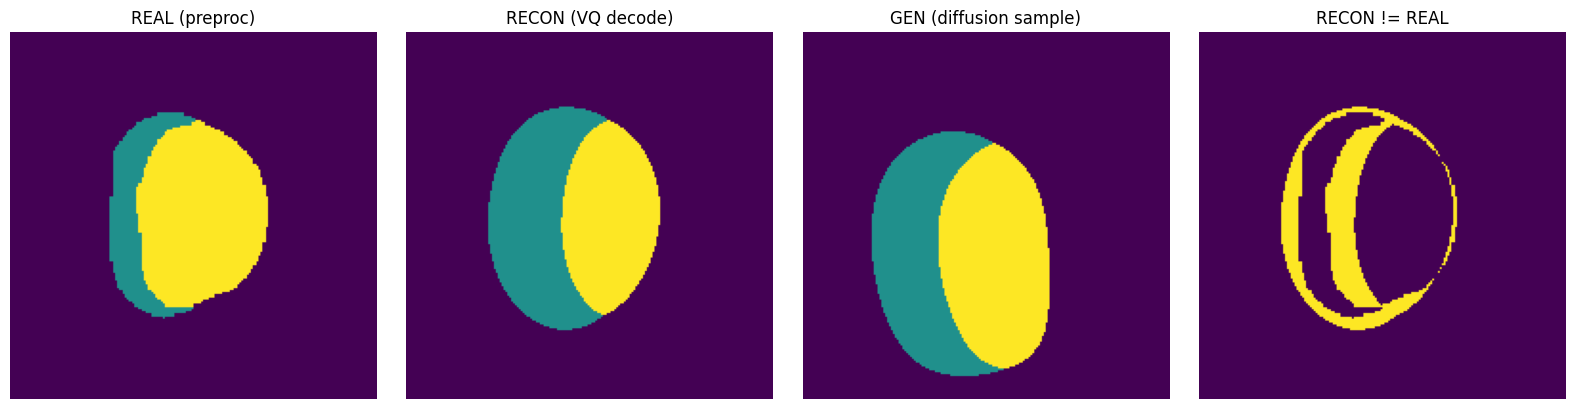

Latest sampled tokens: ./data/Prostate/outputprostatefinal/samples_tokens_ep019.pt shape: (2, 12, 12, 4)
Token match fraction (gen[0] vs real[0]): 0.8385 (1.0 would be suspicious)


In [10]:
import os, glob
import numpy as np
import torch
import nibabel as nib
import matplotlib.pyplot as plt

from trainprostVQ import Net, ProstateDataset

# ----------------------------
# Configuration
# ----------------------------
root = "./data/Prostate/outputprostatefinal"
device = "cuda" if torch.cuda.is_available() else "cpu"

# 1) Load the VQUNet checkpoint using the same selection rule as decode_samples.py.
ckpts = sorted(glob.glob(os.path.join(root, "best_dice_epoch*.ckpt")))
assert len(ckpts) > 0, f"No best_dice checkpoints found in {root}"
ckpt_path = ckpts[-1]
print("Using ckpt:", ckpt_path)

net = Net.load_from_checkpoint(ckpt_path, strict=False).to(device)
net.eval()

# 2) Load one already decoded diffusion-generated sample (NIfTI volume).
gen_dir = os.path.join(root, "decoded_samples")
gen_niis = sorted(glob.glob(os.path.join(gen_dir, "sample_*.nii.gz")))
assert len(gen_niis) > 0, f"No sample_*.nii.gz files found in {gen_dir}"
gen_path = gen_niis[0]   # Change the index here if you want another sample.
gen = nib.load(gen_path).get_fdata().astype(np.uint8)  # [H, W, D]
print("Generated sample:", gen_path, gen.shape, "unique:", np.unique(gen))

# 3) Take one REAL preprocessed example from the validation dataset and reconstruct it via tokens.
#    Using the validation split avoids random training augmentations.
ds = ProstateDataset("validation.csv", split="val")
item = ds[0]  # Change the index here if you want another case.

real = item["label"]
# MONAI may return a MetaTensor, so convert it to a regular tensor if needed.
if hasattr(real, "as_tensor"):
    real = real.as_tensor()
real = torch.as_tensor(real).to(device)  # Typical shape: [1, 192, 192, 64] or [192, 192, 64]

if real.ndim == 3:
    real = real.unsqueeze(0)  # [1, H, W, D]
real_np = real.squeeze(0).detach().cpu().numpy().astype(np.uint8)

# 3a) Encode the real mask into tokens, then decode it back to a segmentation volume.
with torch.no_grad():
    x = net.build_x(real)                        # Multi-channel input (one-hot + boundary map if enabled)
    tok_real = net.encode_x(x, add_noise=False) # [B, 12, 12, 4] in the current configuration
    recon = net.decode_indices_to_seg(tok_real) # [B, 1, 192, 192, 64]

recon_np = recon.squeeze(0).squeeze(0).detach().cpu().numpy().astype(np.uint8)

print("Real label unique:", np.unique(real_np))
print("Reconstruction unique:", np.unique(recon_np))
print("tok_real shape:", tuple(tok_real.shape), "tok_real min/max:", int(tok_real.min()), int(tok_real.max()))

# 3b) Save the real preprocessed mask and its reconstruction as NIfTI files for 3D inspection.
out_recon = os.path.join(gen_dir, "recon_from_real_0.nii.gz")
out_real  = os.path.join(gen_dir, "real_preprocessed_0.nii.gz")
nib.save(nib.Nifti1Image(recon_np, np.eye(4)), out_recon)
nib.save(nib.Nifti1Image(real_np,  np.eye(4)), out_real)
print("Saved:", out_recon)
print("Saved:", out_real)

# ----------------------------
# Simple metrics
# ----------------------------
def dice_bin(a, b):
    a = a.astype(bool); b = b.astype(bool)
    inter = np.logical_and(a, b).sum()
    den = a.sum() + b.sum()
    return (2.0 * inter / den) if den > 0 else 1.0

# Compute class-wise Dice for foreground labels 1 and 2.
for c in [1, 2]:
    d = dice_bin(real_np == c, recon_np == c)
    print(f"Dice recon vs real (class {c}): {d:.4f}")

# ----------------------------
# Quick visual comparison on the same axial slice
# ----------------------------
z = real_np.shape[-1] // 2  # Middle axial slice
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(real_np[:, :, z]);  ax[0].set_title("REAL (preproc)"); ax[0].axis("off")
ax[1].imshow(recon_np[:, :, z]); ax[1].set_title("RECON (VQ decode)"); ax[1].axis("off")
ax[2].imshow(gen[:, :, z]);      ax[2].set_title("GEN (diffusion sample)"); ax[2].axis("off")

# Simple difference map: voxels where the reconstruction label differs from the real label.
diff = (recon_np[:, :, z] != real_np[:, :, z]).astype(np.uint8)
ax[3].imshow(diff); ax[3].set_title("RECON != REAL"); ax[3].axis("off")
plt.tight_layout()
plt.show()

# ----------------------------
# Optional: compare sampled tokens vs real tokens to check that generation is not a direct copy
# ----------------------------
tok_samples = sorted(glob.glob(os.path.join(root, "samples_tokens_ep*.pt")))
if len(tok_samples) > 0:
    tok_path = tok_samples[-1]
    tok_gen = torch.load(tok_path, map_location="cpu").long()  # [B, 12, 12, 4]
    tg = tok_gen[0].numpy()
    tr = tok_real.squeeze(0).detach().cpu().numpy()
    same_frac = (tg == tr).mean()
    print("Latest sampled tokens:", tok_path, "shape:", tuple(tok_gen.shape))
    print(f"Token match fraction (gen[0] vs real[0]): {same_frac:.4f} (1.0 would be suspicious)")
else:
    print("No samples_tokens_ep*.pt files were found for direct token comparison.")


## Token Usage Diagnostics

These diagnostics compare token frequencies between the training set and generated token samples. They are useful for detecting token collapse, background-token dominance, or strong distribution mismatch between training and generation.


In [11]:
import os, glob, torch

# Compare token usage statistics between training tokens and generated tokens.
root = "./data/Prostate/outputprostatefinal"
K = 32

tok_train = torch.load(os.path.join(root, "tokens_train.pt"))
hist_train = torch.bincount(tok_train.view(-1), minlength=K).float()
p_train = hist_train / hist_train.sum()
bg_tok = int(torch.argmax(hist_train))

print("TRAIN: unique tokens =", int((hist_train>0).sum()), "/", K)
print("TRAIN: bg token id =", bg_tok, "freq =", float(p_train[bg_tok]))

# Load the latest diffusion token sample file.
samp_path = sorted(glob.glob(os.path.join(root, "samples_tokens_ep*.pt")))[-1]
tok_gen = torch.load(samp_path)
hist_gen = torch.bincount(tok_gen.view(-1), minlength=K).float()
p_gen = hist_gen / hist_gen.sum()

print("GEN:", os.path.basename(samp_path))
print("GEN: unique tokens =", int((hist_gen>0).sum()), "/", K)
print("GEN: bg token freq =", float(p_gen[bg_tok]))

# Show the five most frequent generated tokens.
topv, topi = torch.topk(p_gen, k=5)
print("GEN top5 (token, freq):", [(int(i), float(v)) for v,i in zip(topv, topi)])


TRAIN: unique tokens = 9 / 32
TRAIN: bg token id = 29 freq = 0.7732638716697693
GEN: samples_tokens_ep019.pt
GEN: unique tokens = 8 / 32
GEN: bg token freq = 0.8376736044883728
GEN top5 (token, freq): [(29, 0.8376736044883728), (26, 0.0850694477558136), (13, 0.0451388880610466), (12, 0.010416666977107525), (14, 0.0086805559694767)]


## Label Distribution in a Generated Sample

This cell computes the class-frequency distribution of one generated segmentation volume. It provides a fast check of whether the generated sample has a plausible balance between background and foreground labels.


In [12]:
import nibabel as nib, numpy as np, glob, os

# Inspect the label distribution in one generated segmentation volume.
root = "./data/Prostate/outputprostatefinal/decoded_samples"
p = sorted(glob.glob(os.path.join(root, "sample_*.nii.gz")))[0]
seg = nib.load(p).get_fdata().astype(np.int16)

vals, counts = np.unique(seg, return_counts=True)
freq = counts / counts.sum()
print("Label frequencies (generated):", dict(zip(vals.tolist(), freq.tolist())))


Label frequencies (generated): {0: 0.8828642103407118, 1: 0.0606490241156684, 2: 0.05648676554361979}


## Label Distribution in a Real Validation Example

This cell reports the class-frequency distribution of the real validation case saved in the previous reconstruction section. Comparing this distribution with the generated one gives a first indication of realism at the label level.


In [13]:
# Inspect the label distribution in the saved real validation example.
p_real = os.path.join(root, "real_preprocessed_0.nii.gz")
real = nib.load(p_real).get_fdata().astype(np.int16)
vals, counts = np.unique(real, return_counts=True)
freq = counts / counts.sum()
print("Label frequencies (real):", dict(zip(vals.tolist(), freq.tolist())))


Label frequencies (real): {0: 0.9424349466959635, 1: 0.01957914564344618, 2: 0.037985907660590276}


## Diversity Check Between Two Generated Samples

This first diversity check measures the overall voxel-wise equality between two generated volumes. Extremely high agreement may suggest insufficient diversity in generation.


In [14]:
import nibabel as nib, numpy as np, os

# Quick diversity check: measure voxel-wise equality between two generated samples.
root = "./data/Prostate/outputprostatefinal/decoded_samples"
a = nib.load(os.path.join(root,"sample_0.nii.gz")).get_fdata().astype(np.int16)
b = nib.load(os.path.join(root,"sample_1.nii.gz")).get_fdata().astype(np.int16)
print("voxel match fraction:", (a==b).mean())


voxel match fraction: 0.9857665167914497


## Foreground-Aware Diversity Metrics

This second diversity check focuses on foreground agreement and foreground Dice. It is more informative than global voxel equality when the background class dominates most of the volume.


In [15]:
import nibabel as nib, numpy as np, os

# Compare two generated samples, with metrics that emphasize foreground structure.
root = "./data/Prostate/outputprostatefinal/decoded_samples"
a = nib.load(os.path.join(root,"sample_0.nii.gz")).get_fdata().astype(np.int16)
b = nib.load(os.path.join(root,"sample_1.nii.gz")).get_fdata().astype(np.int16)

mask_fg = (a>0) | (b>0)
match_all = (a==b).mean()
match_fg  = (a[mask_fg]==b[mask_fg]).mean() if mask_fg.any() else 1.0

def dice_bin(x, y):
    x = x.astype(bool); y = y.astype(bool)
    inter = np.logical_and(x,y).sum()
    den = x.sum()+y.sum()
    return (2*inter/den) if den>0 else 1.0

dice_fg = dice_bin(a>0, b>0)

print("match_all:", match_all)
print("match_fg :", match_fg)
print("dice_fg  :", dice_fg)


match_all: 0.9857665167914497
match_fg : 0.884575989220997
dice_fg  : 0.9470514574421113


## Nearest-Training-Token Similarity Check

This final diagnostic compares each generated token grid against all training token grids and reports the closest match fraction. It is a simple memorization check: unusually high similarity may indicate that generation is too close to the training set.


In [16]:
# Estimate whether generated token grids are near-duplicates of training token grids.
root = "./data/Prostate/outputprostatefinal"
train = torch.load(os.path.join(root, "tokens_train.pt")).long()         # [N, 12, 12, 4]
gen   = torch.load(os.path.join(root, "samples_tokens_best.pt")).long() # [B, 12, 12, 4]

train_flat = train.view(train.shape[0], -1)
gen_flat   = gen.view(gen.shape[0], -1)

for b in range(gen.shape[0]):
    eq = (train_flat == gen_flat[b].unsqueeze(0)).float().mean(dim=1)
    m, idx = torch.max(eq, dim=0)
    print(f"gen[{b}] nearest train idx={int(idx)} match={float(m):.4f}")


gen[0] nearest train idx=29 match=0.8264
gen[1] nearest train idx=29 match=0.8524
gen[2] nearest train idx=49 match=0.8142
gen[3] nearest train idx=28 match=0.8490
gen[4] nearest train idx=29 match=0.8247
gen[5] nearest train idx=29 match=0.8247
gen[6] nearest train idx=29 match=0.8333
gen[7] nearest train idx=29 match=0.8316


In [17]:
root = "./data/Prostate/outputprostatefinal"
train = torch.load(os.path.join(root, "tokens_train.pt")).long()         # [N,12,12,4]
gen   = torch.load(os.path.join(root, "samples_tokens_best.pt")).long() # [B,12,12,4]

train_flat = train.view(train.shape[0], -1)
gen_flat   = gen.view(gen.shape[0], -1)

for b in range(gen.shape[0]):
    eq = (train_flat == gen_flat[b].unsqueeze(0)).float().mean(dim=1)
    m, idx = torch.max(eq, dim=0)
    print(f"gen[{b}] nearest train idx={int(idx)} match={float(m):.4f}")

gen[0] nearest train idx=29 match=0.8264
gen[1] nearest train idx=29 match=0.8524
gen[2] nearest train idx=49 match=0.8142
gen[3] nearest train idx=28 match=0.8490
gen[4] nearest train idx=29 match=0.8247
gen[5] nearest train idx=29 match=0.8247
gen[6] nearest train idx=29 match=0.8333
gen[7] nearest train idx=29 match=0.8316
